In [9]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

result_dir = Path("results/task2/results")
results = []

# Process .log files
for log_file in result_dir.glob("*.out"):
    # Extract the identifier from the filename (last number before extension)
    file_id = log_file.stem.split('_')[-1]
    
    data = {'folder': file_id}
    
    with open(log_file, "r") as f:
        content = f.read()
        
        # Extract time with Tensor Cores
        tc_match = re.search(r"Time taken with TC: (\d+\.\d+) ms", content)
        if tc_match:
            data['time_with_tc'] = float(tc_match.group(1))
        else:
            data['time_with_tc'] = None
            
        # Extract time without Tensor Cores
        no_tc_match = re.search(r"Time taken without TC: (\d+\.\d+) ms", content)
        if no_tc_match:
            data['time_without_tc'] = float(no_tc_match.group(1))
        else:
            data['time_without_tc'] = None
            
    results.append(data)

# Create DataFrame and calculate speedup if both times are available
df = pd.DataFrame(results)
if 'time_with_tc' in df.columns and 'time_without_tc' in df.columns:
    df['speedup'] = df['time_without_tc'] / df['time_with_tc']

print(df)

  folder  time_with_tc  time_without_tc    speedup
0      1      0.040768         1.531424  37.564364
1      3      2.183104        93.480896  42.820175
2      2      0.295744        11.727008  39.652564
3      4     17.041183       879.540283  51.612631
4      0      0.015168         0.215968  14.238397


In [10]:
df

,folder,time_with_tc,time_without_tc,speedup
0,1,0.040768,1.531424,37.564364
1,3,2.183104,93.480896,42.820175
2,2,0.295744,11.727008,39.652564
3,4,17.041183,879.540283,51.612631
4,0,0.015168,0.215968,14.238397


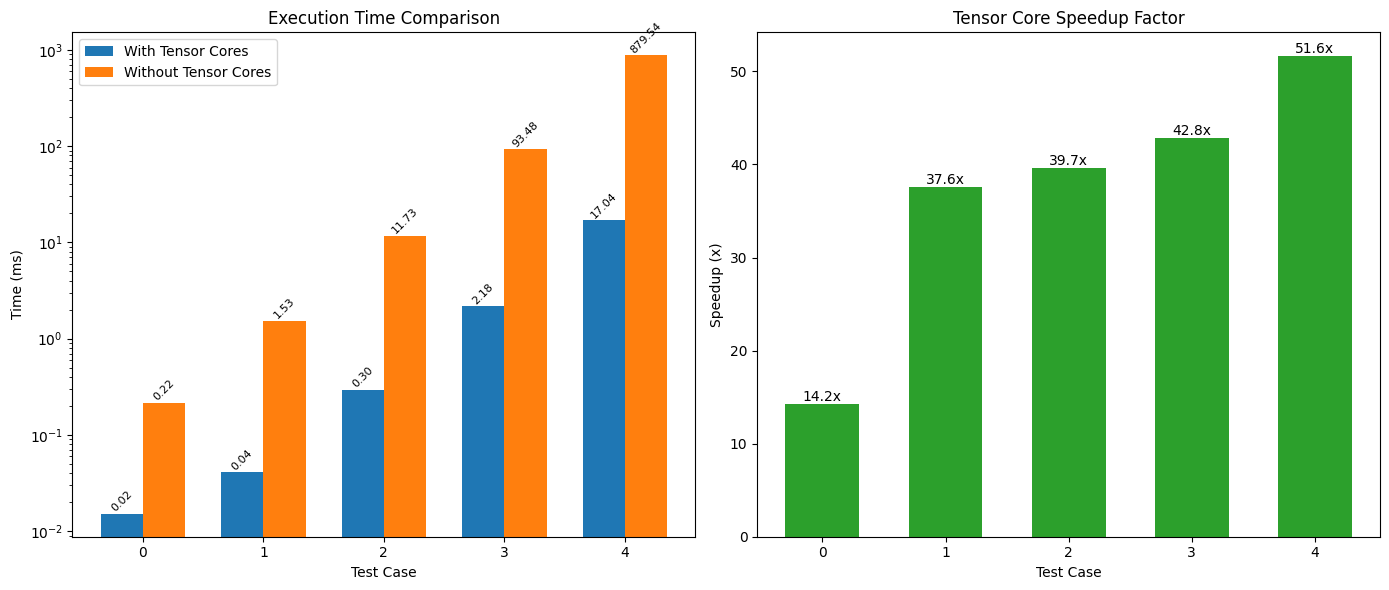

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Sort the DataFrame by folder for better visualization
df = df.sort_values('folder')

# Set up the figure and subplots
plt.figure(figsize=(14, 6))

# First subplot: Time comparison
plt.subplot(1, 2, 1)
bar_width = 0.35
index = np.arange(len(df))

bars1 = plt.bar(index, df['time_with_tc'], bar_width, label='With Tensor Cores', color='#1f77b4')
bars2 = plt.bar(index + bar_width, df['time_without_tc'], bar_width, label='Without Tensor Cores', color='#ff7f0e')

plt.xlabel('Test Case')
plt.ylabel('Time (ms)')
plt.title('Execution Time Comparison')
plt.xticks(index + bar_width/2, df['folder'])
plt.yscale('log')  # Using log scale due to large differences
plt.legend()

# Add value labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}',
                 ha='center', va='bottom', rotation=45, fontsize=8)

# Second subplot: Speedup
plt.subplot(1, 2, 2)
speedup_bars = plt.bar(index, df['speedup'], width=0.6, color='#2ca02c')

plt.xlabel('Test Case')
plt.ylabel('Speedup (x)')
plt.title('Tensor Core Speedup Factor')
plt.xticks(index, df['folder'])

# Add value labels on top of bars
for bar in speedup_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}x',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [15]:
a = df.to_latex(
    index=False,
    caption='Execution Time Comparison',
    label='tab:tensorcores_comparison',
    position='h!',
    column_format='l' + 'r' * (len(df.columns) - 1),
    float_format="{:,.0f}".format,
    na_rep='-'
)
print(a)

\begin{table}[h!]
\caption{Execution Time Comparison}
\label{tab:tensorcores_comparison}
\begin{tabular}{lrrr}
\toprule
folder & time_with_tc & time_without_tc & speedup \\
\midrule
0 & 0 & 0 & 14 \\
1 & 0 & 2 & 38 \\
2 & 0 & 12 & 40 \\
3 & 2 & 93 & 43 \\
4 & 17 & 880 & 52 \\
\bottomrule
\end{tabular}
\end{table}

